In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv(r'C:\Users\vsmuh\Downloads\Project 1\data\processed\nhanes_features.csv')

print(f"✅ Loaded: {df.shape}")
print(f"Target distribution:\n{df['diabetes_status'].value_counts()}")

✅ Loaded: (6041, 28)
Target distribution:
diabetes_status
0    3656
1    1634
2     751
Name: count, dtype: int64


In [4]:
X = df.drop(columns=['diabetes_status'])
y = df['diabetes_status']

# Stratified split — keeps class proportions in both train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set  : {X_train.shape}")
print(f"Test set      : {X_test.shape}")
print(f"\nTrain target distribution:\n{y_train.value_counts()}")
print(f"\nTest target distribution:\n{y_test.value_counts()}")

Training set  : (4832, 27)
Test set      : (1209, 27)

Train target distribution:
diabetes_status
0    2924
1    1307
2     601
Name: count, dtype: int64

Test target distribution:
diabetes_status
0    732
1    327
2    150
Name: count, dtype: int64


In [5]:
# Calculate class weights to handle imbalance
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)
class_weight_dict = dict(zip(classes, weights))

print("Class weights:")
for cls, weight in class_weight_dict.items():
    label = {0:'Normal', 1:'Pre-diabetic', 2:'Diabetic'}[cls]
    print(f"  {label}: {weight:.3f}")

Class weights:
  Normal: 0.551
  Pre-diabetic: 1.232
  Diabetic: 2.680


In [6]:
# Scale features — Logistic Regression needs this
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Train
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
lr.fit(X_train_scaled, y_train)

# Evaluate
y_pred_lr = lr.predict(X_test_scaled)

print("=" * 50)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 50)
print(classification_report(
    y_test, y_pred_lr,
    target_names=['Normal', 'Pre-diabetic', 'Diabetic']
))

LOGISTIC REGRESSION RESULTS
              precision    recall  f1-score   support

      Normal       0.83      0.69      0.75       732
Pre-diabetic       0.37      0.30      0.33       327
    Diabetic       0.30      0.70      0.42       150

    accuracy                           0.58      1209
   macro avg       0.50      0.56      0.50      1209
weighted avg       0.64      0.58      0.60      1209



In [7]:
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("=" * 50)
print("RANDOM FOREST RESULTS")
print("=" * 50)
print(classification_report(
    y_test, y_pred_rf,
    target_names=['Normal', 'Pre-diabetic', 'Diabetic']
))

RANDOM FOREST RESULTS
              precision    recall  f1-score   support

      Normal       0.72      0.84      0.78       732
Pre-diabetic       0.39      0.35      0.37       327
    Diabetic       0.31      0.13      0.19       150

    accuracy                           0.62      1209
   macro avg       0.47      0.44      0.44      1209
weighted avg       0.58      0.62      0.60      1209



In [8]:
# Convert class weights to sample weights for XGBoost
from sklearn.utils import compute_sample_weight
sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train
)

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train, sample_weight=sample_weights)

y_pred_xgb = xgb_model.predict(X_test)

print("=" * 50)
print("XGBOOST RESULTS")
print("=" * 50)
print(classification_report(
    y_test, y_pred_xgb,
    target_names=['Normal', 'Pre-diabetic', 'Diabetic']
))

XGBOOST RESULTS
              precision    recall  f1-score   support

      Normal       0.81      0.72      0.76       732
Pre-diabetic       0.38      0.40      0.39       327
    Diabetic       0.29      0.41      0.34       150

    accuracy                           0.59      1209
   macro avg       0.49      0.51      0.50      1209
weighted avg       0.63      0.59      0.61      1209



In [9]:
from sklearn.metrics import f1_score, recall_score

models = {
    'Logistic Regression': y_pred_lr,
    'Random Forest'      : y_pred_rf,
    'XGBoost'            : y_pred_xgb
}

print(f"{'Model':<25} {'F1 (macro)':<15} {'Recall (macro)':<15}")
print("-" * 55)
for name, preds in models.items():
    f1     = f1_score(y_test, preds, average='macro')
    recall = recall_score(y_test, preds, average='macro')
    print(f"{name:<25} {f1:<15.3f} {recall:<15.3f}")

Model                     F1 (macro)      Recall (macro) 
-------------------------------------------------------
Logistic Regression       0.502           0.561          
Random Forest             0.445           0.442          
XGBoost                   0.498           0.511          


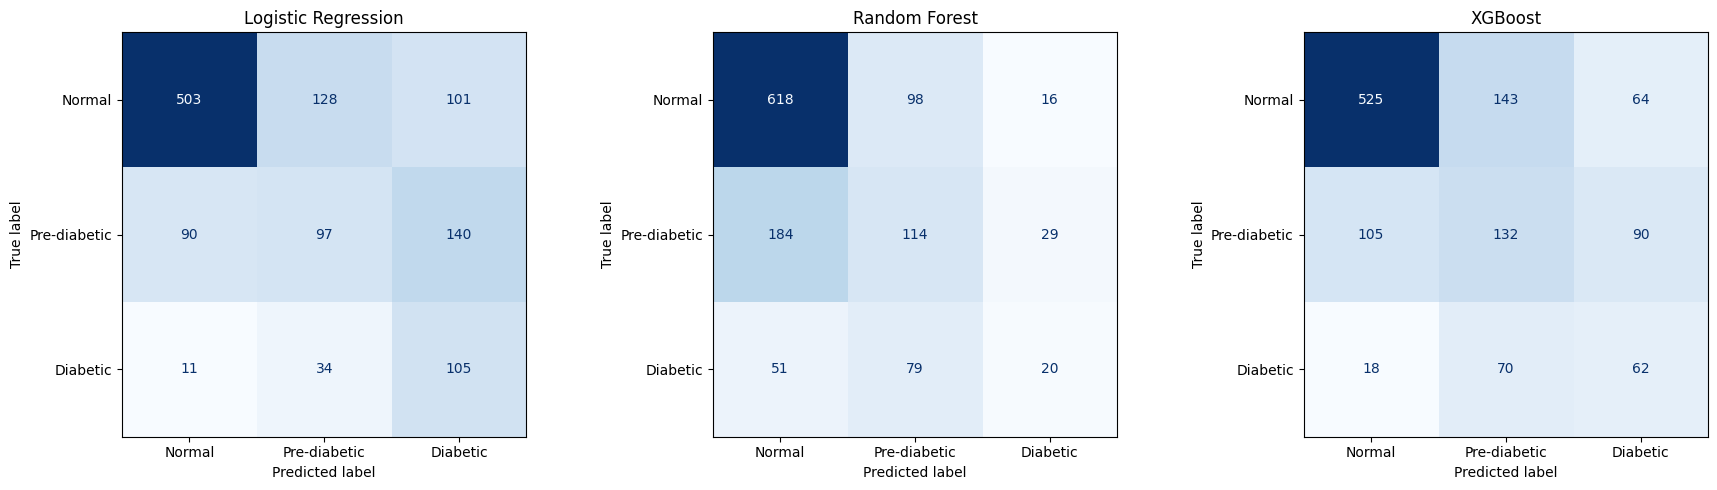

In [10]:
# Plot confusion matrix for XGBoost
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, preds) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Normal', 'Pre-diabetic', 'Diabetic']
    )
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)

plt.tight_layout()
plt.savefig('../reports/confusion_matrices.png')
plt.show()

In [11]:
import joblib
import os

os.makedirs('../models', exist_ok=True)

# Save the best model and scaler
joblib.dump(lr, '../models/logistic_regression_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')

print("✅ Best model saved!")
print("   → models/logistic_regression_model.pkl")
print("   → models/scaler.pkl")

✅ Best model saved!
   → models/logistic_regression_model.pkl
   → models/scaler.pkl
